In [ ]:
SmartBake – Bakery Demand Prediction
Predict Low, Medium, or High bakery demand using Decision Tree, Pruned Decision Tree, and SVM.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)

warnings.filterwarnings("ignore")


In [3]:
# Load the FINAL bakery demand dataset
df = pd.read_csv("bakery_demand.csv")
print("Dataset Shape:", df.shape)
print(df.columns.tolist())
display(df.head())

Dataset Shape: (1000, 12)
['Date', 'Product', 'Day', 'Weekend', 'Prev_Sales', '7_Day_Avg', 'Price', 'Promo', 'Temp_C', 'Rain_mm', 'Holiday', 'Demand']


,Date,Product,Day,Weekend,Prev_Sales,7_Day_Avg,Price,Promo,Temp_C,Rain_mm,Holiday,Demand
0,2026-09-01,Croissant,Tue,0,60.0,60.0,70.0,0,24.7,0.0,0,84
1,2026-09-02,Bread,Wed,0,84.0,84.0,40.0,0,30.9,1.4,0,71
2,2026-09-03,Croissant,Thu,0,71.0,77.5,70.0,0,24.2,11.2,0,74
3,2026-09-04,Pastry,Fri,0,74.0,76.3,60.0,0,27.1,1.0,0,77
4,2026-09-05,Muffin,Sat,1,77.0,76.5,45.0,0,26.1,0.0,0,44


In [4]:
# Missing values and summary
print("Missing values:")
display(df.isnull().sum())
display(df.describe(include="all"))

Missing values:


Date          0
Product       0
Day           0
Weekend       0
Prev_Sales    5
7_Day_Avg     5
Price         0
Promo         0
Temp_C        5
Rain_mm       5
Holiday       0
Demand        0
dtype: int64

,Date,Product,Day,Weekend,Prev_Sales,7_Day_Avg,Price,Promo,Temp_C,Rain_mm,Holiday,Demand
count,1000,1000,1000,1000.000000,995.000000,995.000000,1000.000000,1000.000000,995.000000,995.000000,1000.000000,1000.000000
unique,1000,4,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,2026-09-01,Muffin,Tue,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,263,143,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,0.286000,74.037186,74.057990,53.825000,0.314000,28.066935,2.341608,0.011000,74.076000
std,NaN,NaN,NaN,0.452115,22.373985,9.551234,11.953546,0.464349,3.191746,3.113855,0.104355,22.339635
min,NaN,NaN,NaN,0.000000,24.000000,43.300000,40.000000,0.000000,20.000000,0.000000,0.000000,24.000000
25%,NaN,NaN,NaN,0.000000,56.000000,67.600000,45.000000,0.000000,25.900000,0.000000,0.000000,56.000000
50%,NaN,NaN,NaN,0.000000,75.000000,74.100000,45.000000,0.000000,28.100000,1.300000,0.000000,75.000000
75%,NaN,NaN,NaN,1.000000,91.500000,80.900000,70.000000,1.000000,30.200000,3.300000,0.000000,91.250000


In [5]:
# Target classification
def demand_class(d):
    if d <= 50:
        return "Low"
    elif d <= 100:
        return "Medium"
    return "High"

df["Demand_Class"] = df["Demand"].apply(demand_class)
print(df["Demand_Class"].value_counts())

Demand_Class
Medium    689
Low       189
High      122
Name: count, dtype: int64


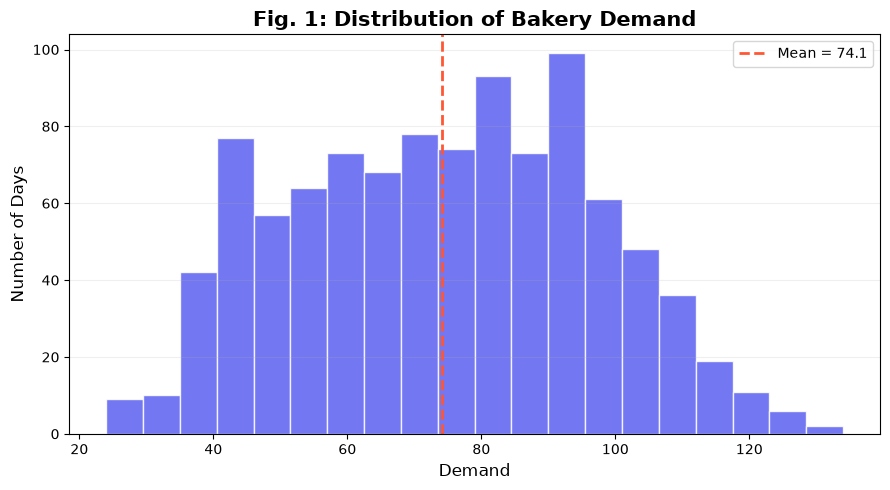

In [6]:
# Fig. 1: Distribution of Bakery Demand

plt.figure(figsize=(9, 5))

plt.hist(
    df["Demand"].dropna(),
    bins=20,
    color="#5B5FEF",
    edgecolor="white",
    alpha=0.85
)

plt.axvline(
    df["Demand"].mean(),
    color="#FF5733",
    linestyle="--",
    linewidth=2,
    label=f"Mean = {df['Demand'].mean():.1f}"
)

plt.xlabel("Demand", fontsize=12)
plt.ylabel("Number of Days", fontsize=12)
plt.title("Fig. 1: Distribution of Bakery Demand", fontsize=15, fontweight="bold")

plt.legend()
plt.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()

In [ ]:
Exploratory Data Analysis

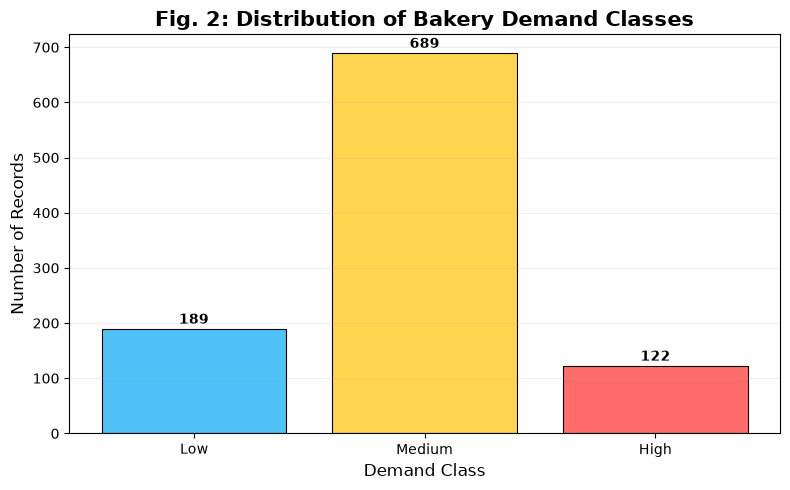

In [7]:
# Fig. 2: Demand Class Distribution

class_order = ["Low", "Medium", "High"]
class_counts = df["Demand_Class"].value_counts().reindex(class_order)

plt.figure(figsize=(8, 5))

bars = plt.bar(
    class_counts.index,
    class_counts.values,
    color=["#4FC3F7", "#FFD54F", "#FF6B6B"],
    edgecolor="black",
    linewidth=0.8
)

plt.xlabel("Demand Class", fontsize=12)
plt.ylabel("Number of Records", fontsize=12)
plt.title("Fig. 2: Distribution of Bakery Demand Classes",
          fontsize=15, fontweight="bold")

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 10,
        int(bar.get_height()),
        ha="center",
        fontweight="bold"
    )

plt.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()


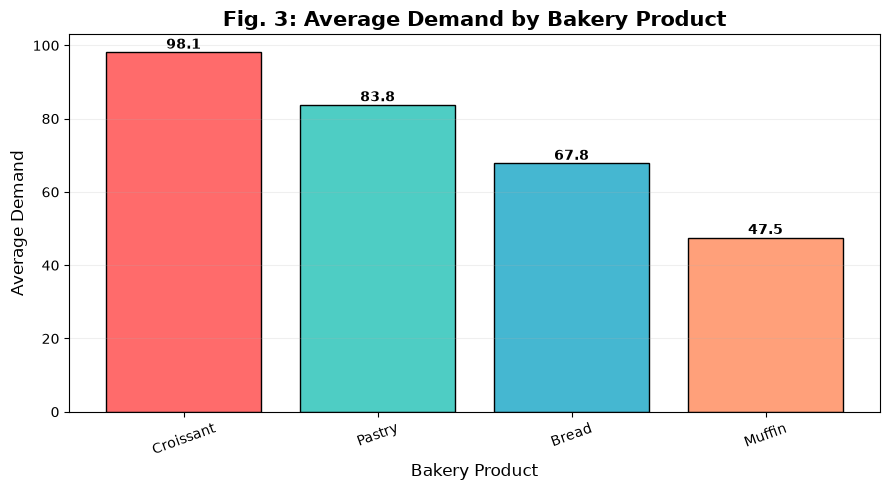

In [8]:
# Fig. 3: Average Demand by Product

product_demand = (
    df.groupby("Product")["Demand"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(9, 5))

colors = [
    "#FF6B6B",
    "#4ECDC4",
    "#45B7D1",
    "#FFA07A",
    "#9B59B6",
    "#F4D03F"
]

bars = plt.bar(
    product_demand.index,
    product_demand.values,
    color=colors[:len(product_demand)],
    edgecolor="black"
)

plt.xlabel("Bakery Product", fontsize=12)
plt.ylabel("Average Demand", fontsize=12)
plt.title("Fig. 3: Average Demand by Bakery Product",
          fontsize=15, fontweight="bold")

plt.xticks(rotation=20)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 1,
        f"{bar.get_height():.1f}",
        ha="center",
        fontsize=10,
        fontweight="bold"
    )

plt.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()

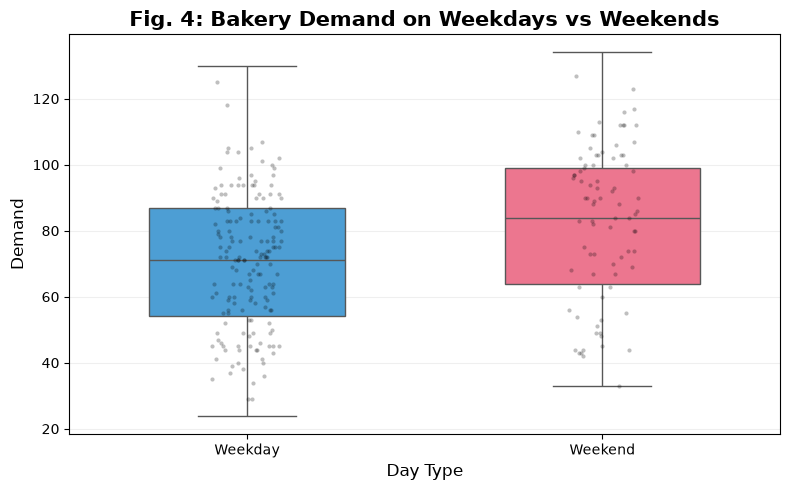

In [9]:
# Fig. 4: Weekday vs Weekend Demand

df["Day_Type"] = df["Weekend"].map({
    0: "Weekday",
    1: "Weekend"
})

weekday_order = ["Weekday", "Weekend"]

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Day_Type",
    y="Demand",
    order=weekday_order,
    palette=["#36A2EB", "#FF6384"],
    width=0.55
)

sns.stripplot(
    data=df.sample(min(250, len(df)), random_state=42),
    x="Day_Type",
    y="Demand",
    order=weekday_order,
    color="black",
    alpha=0.25,
    size=3
)

plt.xlabel("Day Type", fontsize=12)
plt.ylabel("Demand", fontsize=12)
plt.title("Fig. 4: Bakery Demand on Weekdays vs Weekends",
          fontsize=15, fontweight="bold")

plt.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()

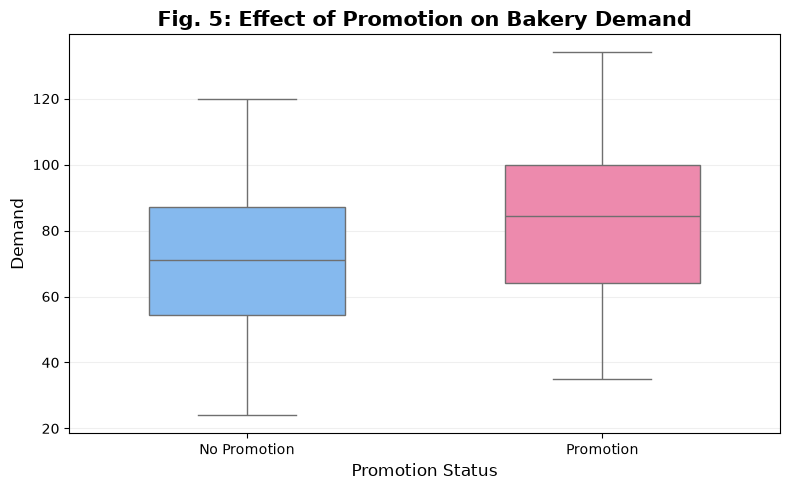

In [10]:
# Fig. 5: Promotion vs Demand

promo_data = df.copy()

promo_data["Promotion"] = promo_data["Promo"].map({
    0: "No Promotion",
    1: "Promotion"
})

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=promo_data,
    x="Promotion",
    y="Demand",
    palette=["#74B9FF", "#FD79A8"],
    width=0.55
)

plt.xlabel("Promotion Status", fontsize=12)
plt.ylabel("Demand", fontsize=12)
plt.title("Fig. 5: Effect of Promotion on Bakery Demand",
          fontsize=15, fontweight="bold")

plt.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()

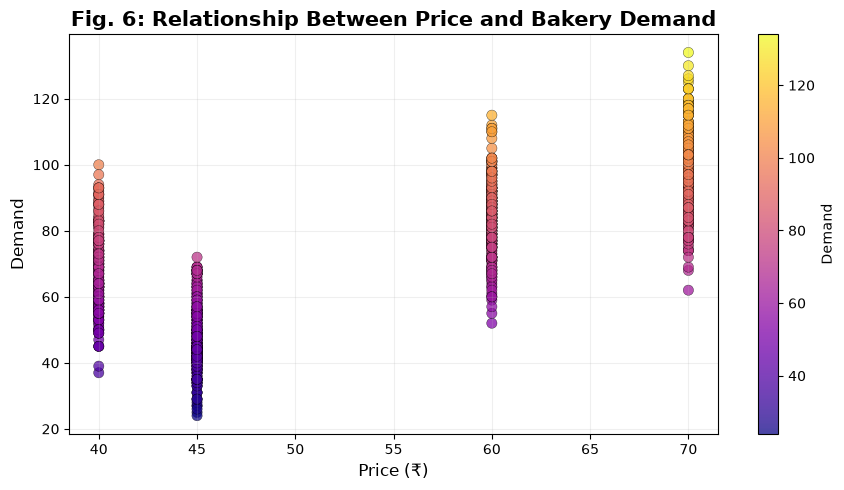

In [11]:
# Fig. 6: Price vs Demand

plt.figure(figsize=(9, 5))

scatter = plt.scatter(
    df["Price"],
    df["Demand"],
    c=df["Demand"],
    cmap="plasma",
    s=55,
    alpha=0.75,
    edgecolors="black",
    linewidths=0.3
)

plt.colorbar(scatter, label="Demand")

plt.xlabel("Price (₹)", fontsize=12)
plt.ylabel("Demand", fontsize=12)
plt.title("Fig. 6: Relationship Between Price and Bakery Demand",
          fontsize=15, fontweight="bold")

plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

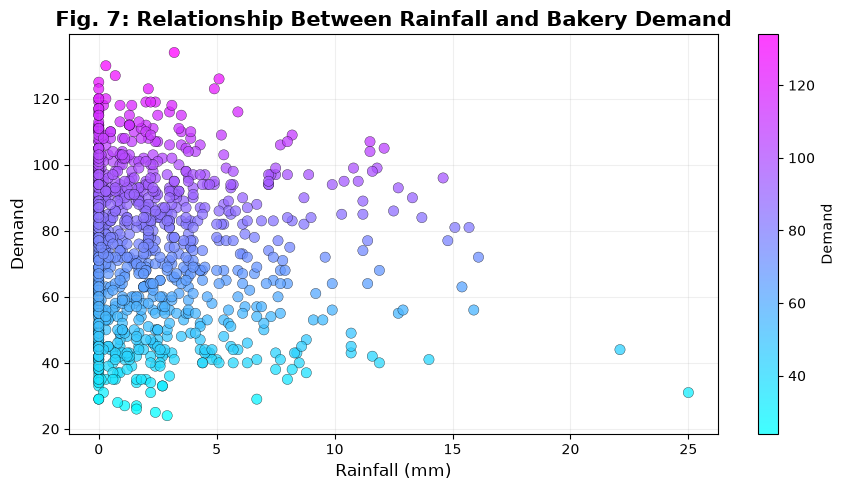

In [12]:
# Fig. 7: Rainfall vs Demand

plt.figure(figsize=(9, 5))

scatter = plt.scatter(
    df["Rain_mm"],
    df["Demand"],
    c=df["Demand"],
    cmap="cool",
    s=55,
    alpha=0.75,
    edgecolors="black",
    linewidths=0.3
)

plt.colorbar(scatter, label="Demand")

plt.xlabel("Rainfall (mm)", fontsize=12)
plt.ylabel("Demand", fontsize=12)
plt.title("Fig. 7: Relationship Between Rainfall and Bakery Demand",
          fontsize=15, fontweight="bold")

plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

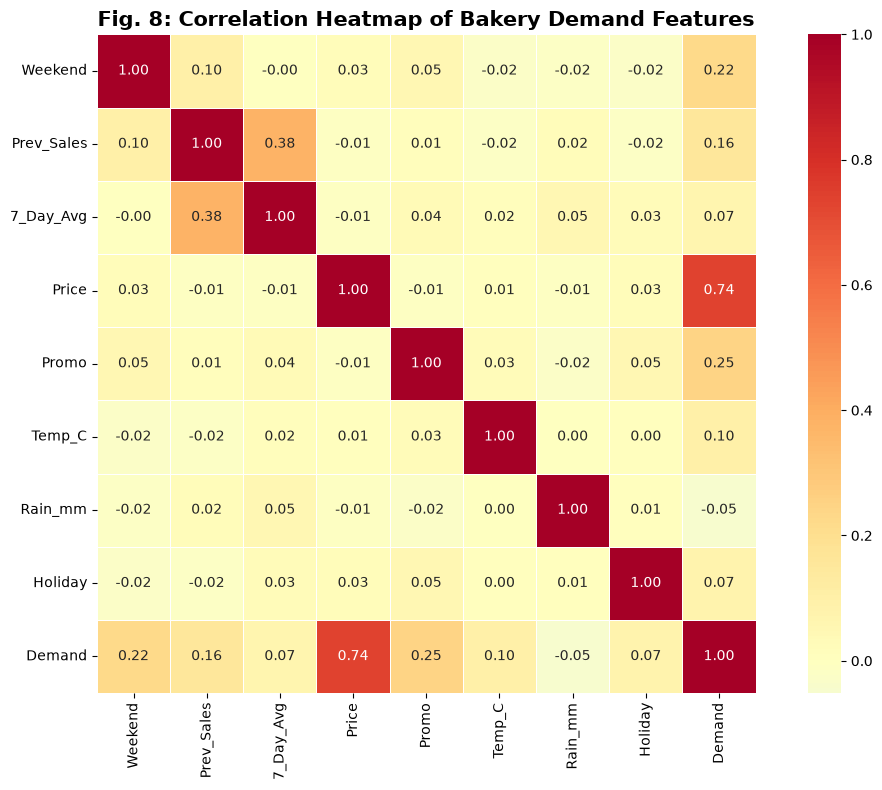

In [13]:
# Fig. 8: Correlation Heatmap

numeric_cols = [
    "Weekend",
    "Prev_Sales",
    "7_Day_Avg",
    "Price",
    "Promo",
    "Temp_C",
    "Rain_mm",
    "Holiday",
    "Demand"
]

corr = df[numeric_cols].corr()

plt.figure(figsize=(11, 8))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="RdYlBu_r",
    linewidths=0.5,
    center=0,
    square=True
)

plt.title(
    "Fig. 8: Correlation Heatmap of Bakery Demand Features",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

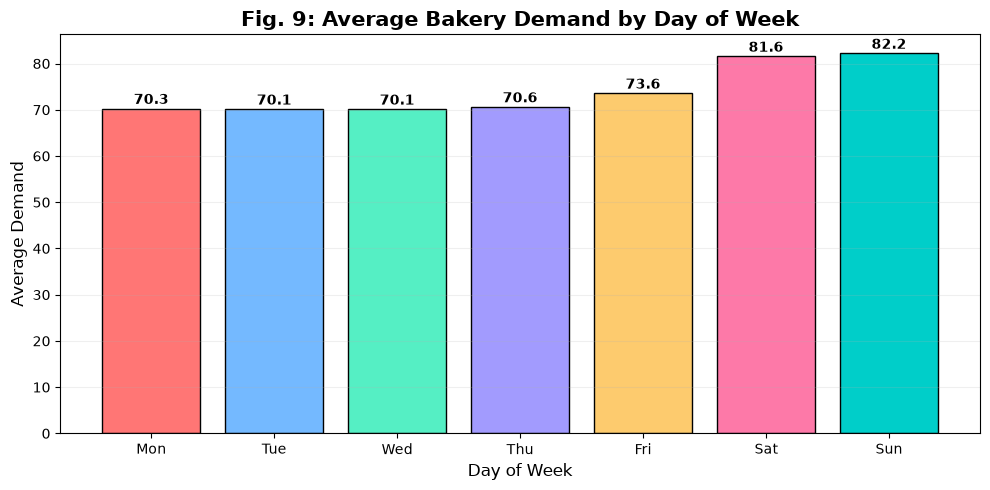

In [14]:
# Fig. 9: Average Demand by Day of Week

day_order = [
    "Mon", "Tue", "Wed",
    "Thu", "Fri", "Sat", "Sun"
]

day_demand = (
    df.groupby("Day")["Demand"]
    .mean()
    .reindex(day_order)
)

plt.figure(figsize=(10, 5))

colors = [
    "#FF7675",
    "#74B9FF",
    "#55EFC4",
    "#A29BFE",
    "#FDCB6E",
    "#FD79A8",
    "#00CEC9"
]

bars = plt.bar(
    day_demand.index,
    day_demand.values,
    color=colors,
    edgecolor="black"
)

plt.xlabel("Day of Week", fontsize=12)
plt.ylabel("Average Demand", fontsize=12)
plt.title(
    "Fig. 9: Average Bakery Demand by Day of Week",
    fontsize=15,
    fontweight="bold"
)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 1,
        f"{bar.get_height():.1f}",
        ha="center",
        fontweight="bold"
    )

plt.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()

In [ ]:
Preprocessing

In [15]:
features = ["Product","Day","Weekend","Prev_Sales","7_Day_Avg",
            "Price","Promo","Temp_C","Rain_mm","Holiday"]
target = "Demand_Class"

X = df[features]
y = df[target]

categorical_features = ["Product","Day"]
numeric_features = [c for c in features if c not in categorical_features]

preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), numeric_features),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ]), categorical_features)
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=.20, random_state=42, stratify=y
)

print("Training:", X_train.shape)
print("Testing :", X_test.shape)


Training: (800, 10)
Testing : (200, 10)


In [ ]:
Decision Tree

In [16]:
dt_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(
        random_state=42, class_weight="balanced", max_depth=8
    ))
])
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)
print(classification_report(y_test, dt_pred, zero_division=0))


              precision    recall  f1-score   support

        High       0.44      0.62      0.52        24
         Low       0.71      0.76      0.73        38
      Medium       0.86      0.78      0.81       138

    accuracy                           0.76       200
   macro avg       0.67      0.72      0.69       200
weighted avg       0.78      0.76      0.76       200



In [ ]:
Pruned Decision Tree

In [18]:
pruned_base = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(
        random_state=42, class_weight="balanced"
    ))
])

param_grid = {
    "classifier__max_depth": [3,4,5,6,8],
    "classifier__min_samples_leaf": [2,5,10],
    "classifier__ccp_alpha": [0,.001,.005,.01]
}

grid = GridSearchCV(
    pruned_base, param_grid, cv=5,
    scoring="f1_macro", n_jobs=-1
)
grid.fit(X_train, y_train)

pruned_model = grid.best_estimator_
print("Best parameters:", grid.best_params_)
pruned_pred = pruned_model.predict(X_test)
print(classification_report(y_test, pruned_pred, zero_division=0))


Best parameters: {'classifier__ccp_alpha': 0.01, 'classifier__max_depth': 4, 'classifier__min_samples_leaf': 2}
              precision    recall  f1-score   support

        High       0.63      0.71      0.67        24
         Low       0.62      0.92      0.74        38
      Medium       0.91      0.78      0.84       138

    accuracy                           0.80       200
   macro avg       0.72      0.80      0.75       200
weighted avg       0.83      0.80      0.80       200



In [ ]:
SVM

In [19]:
svm_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", SVC(
        kernel="rbf", C=1.0, gamma="scale",
        probability=True, class_weight="balanced", random_state=42
    ))
])
svm_model.fit(X_train, y_train)
svm_pred = svm_model.predict(X_test)
print(classification_report(y_test, svm_pred, zero_division=0))


              precision    recall  f1-score   support

        High       0.50      0.83      0.62        24
         Low       0.64      0.95      0.77        38
      Medium       0.94      0.71      0.81       138

    accuracy                           0.77       200
   macro avg       0.70      0.83      0.73       200
weighted avg       0.83      0.77      0.78       200



In [ ]:
Evaluation

In [20]:
models = {
    "Decision Tree": dt_model,
    "Pruned Decision Tree": pruned_model,
    "SVM": svm_model
}

evaluation = []
for name, model in models.items():
    pred = model.predict(X_test)
    evaluation.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test,pred),
        "Precision": precision_score(y_test,pred,average="macro",zero_division=0),
        "Recall": recall_score(y_test,pred,average="macro",zero_division=0),
        "F1 Score": f1_score(y_test,pred,average="macro",zero_division=0)
    })

results_df = pd.DataFrame(evaluation)
display(results_df.round(4))


,Model,Accuracy,Precision,Recall,F1 Score
0,Decision Tree,0.755,0.6682,0.7212,0.6884
1,Pruned Decision Tree,0.795,0.7231,0.8016,0.7502
2,SVM,0.770,0.6951,0.8303,0.7336


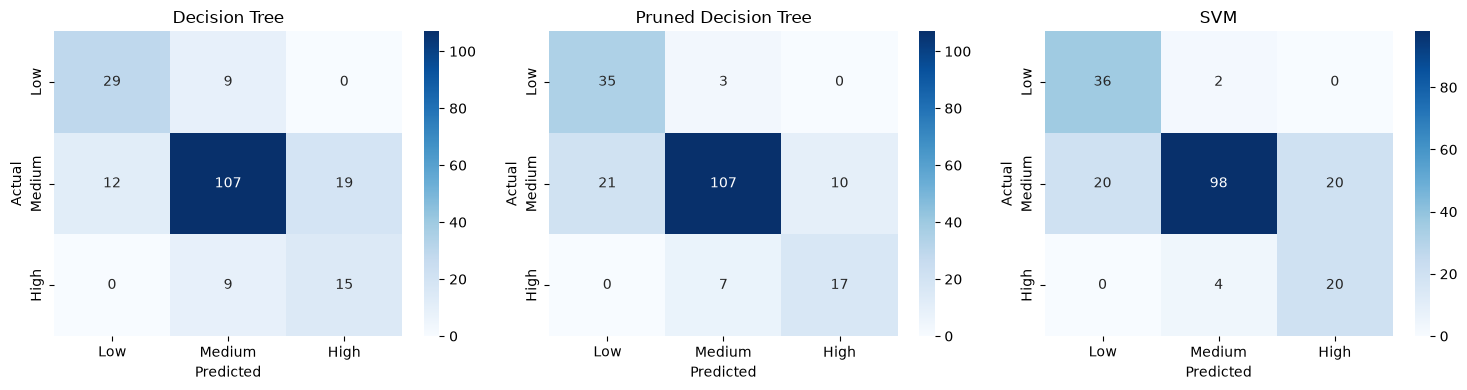

In [21]:
# Confusion matrices
classes = ["Low","Medium","High"]
fig, axes = plt.subplots(1,3,figsize=(15,4))
for ax,(name,model) in zip(axes,models.items()):
    pred = model.predict(X_test)
    cm = confusion_matrix(y_test,pred,labels=classes)
    sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",
                xticklabels=classes,yticklabels=classes,ax=ax)
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()


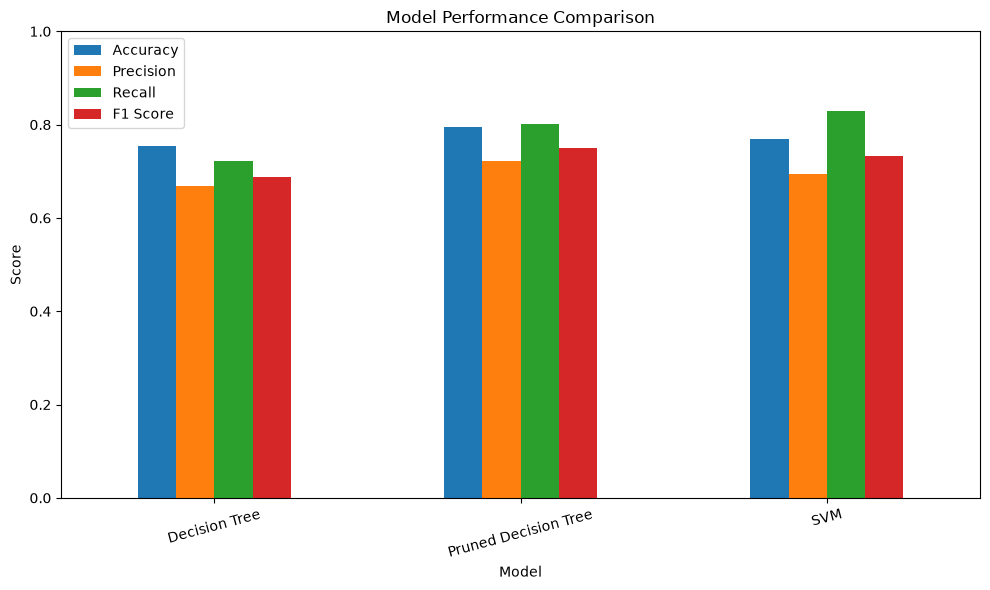

In [22]:
# Model comparison
results_df.set_index("Model")[["Accuracy","Precision","Recall","F1 Score"]].plot(
    kind="bar", figsize=(10,6)
)
plt.ylim(0,1)
plt.ylabel("Score")
plt.title("Model Performance Comparison")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


In [23]:
# Save the trained models for Flask
joblib.dump(dt_model, "decision_tree.pkl")
joblib.dump(pruned_model, "pruned_decision_tree.pkl")
joblib.dump(svm_model, "svm.pkl")
joblib.dump({
    "features": features,
    "classes": ["Low","Medium","High"]
}, "model_info.pkl")
print("Models saved successfully.")


Models saved successfully.


In [24]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline

dt_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(
        random_state=42,
        class_weight="balanced",
        max_depth=8
    ))
])

dt_model.fit(X_train, y_train)

print("Decision Tree trained successfully!")

Decision Tree trained successfully!


In [25]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# Features
X = df[
    [
        "Product",
        "Day",
        "Weekend",
        "Prev_Sales",
        "7_Day_Avg",
        "Price",
        "Promo",
        "Temp_C",
        "Rain_mm",
        "Holiday"
    ]
]

# Target
y = df["Demand_Class"]

# Separate categorical and numerical columns
categorical_features = ["Product", "Day"]

numeric_features = [
    "Weekend",
    "Prev_Sales",
    "7_Day_Avg",
    "Price",
    "Promo",
    "Temp_C",
    "Rain_mm",
    "Holiday"
]

# Numerical preprocessing
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical preprocessing
categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Complete preprocessor
preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

print("Preprocessor created successfully!")

Preprocessor created successfully!


In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (800, 10)
Testing data: (200, 10)


In [27]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline

dt_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(
        random_state=42,
        class_weight="balanced",
        max_depth=8
    ))
])

dt_model.fit(X_train, y_train)

print("Decision Tree trained successfully!")

Decision Tree trained successfully!


In [28]:
dt_accuracy = accuracy_score(y_test, dt_pred)
pruned_accuracy = accuracy_score(y_test, pruned_pred)
svm_accuracy = accuracy_score(y_test, svm_pred)

print("Decision Tree Accuracy:", dt_accuracy)
print("Pruned Decision Tree Accuracy:", pruned_accuracy)
print("SVM Accuracy:", svm_accuracy)

Decision Tree Accuracy: 0.755
Pruned Decision Tree Accuracy: 0.795
SVM Accuracy: 0.77


In [29]:
from sklearn.metrics import precision_score

dt_precision = precision_score(
    y_test, dt_pred,
    average="macro",
    zero_division=0
)

pruned_precision = precision_score(
    y_test, pruned_pred,
    average="macro",
    zero_division=0
)

svm_precision = precision_score(
    y_test, svm_pred,
    average="macro",
    zero_division=0
)

print("Decision Tree Precision:", dt_precision)
print("Pruned Decision Tree Precision:", pruned_precision)
print("SVM Precision:", svm_precision)

Decision Tree Precision: 0.6681645145863223
Pruned Decision Tree Precision: 0.7230531813865148
SVM Precision: 0.6950549450549449


In [30]:
from sklearn.metrics import recall_score

dt_recall = recall_score(
    y_test, dt_pred,
    average="macro",
    zero_division=0
)

pruned_recall = recall_score(
    y_test, pruned_pred,
    average="macro",
    zero_division=0
)

svm_recall = recall_score(
    y_test, svm_pred,
    average="macro",
    zero_division=0
)

print("Decision Tree Recall:", dt_recall)
print("Pruned Decision Tree Recall:", pruned_recall)
print("SVM Recall:", svm_recall)

Decision Tree Recall: 0.7211734045258072
Pruned Decision Tree Recall: 0.8015827612509535
SVM Recall: 0.830282227307399


In [31]:
from sklearn.metrics import f1_score

dt_f1 = f1_score(
    y_test, dt_pred,
    average="macro",
    zero_division=0
)

pruned_f1 = f1_score(
    y_test, pruned_pred,
    average="macro",
    zero_division=0
)

svm_f1 = f1_score(
    y_test, svm_pred,
    average="macro",
    zero_division=0
)

print("Decision Tree F1:", dt_f1)
print("Pruned Decision Tree F1:", pruned_f1)
print("SVM F1:", svm_f1)

Decision Tree F1: 0.6883689358093249
Pruned Decision Tree F1: 0.7501877346683354
SVM F1: 0.7336249340601372


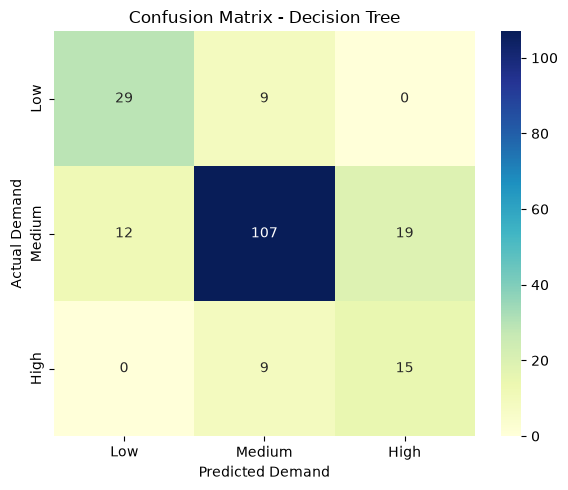

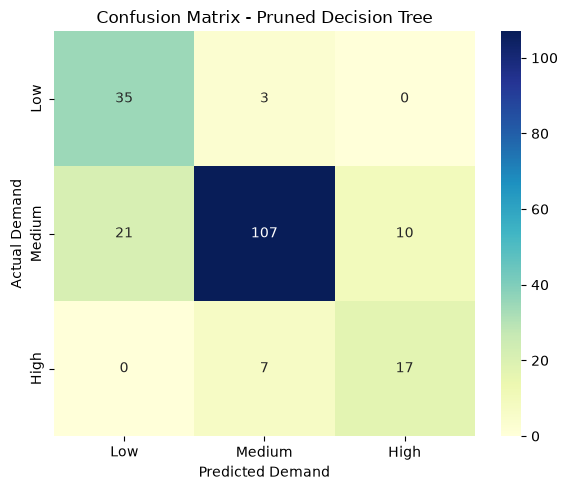

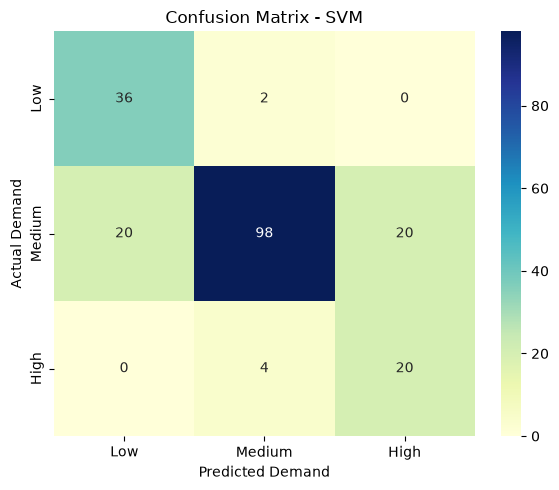

In [32]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

models = {
    "Decision Tree": dt_pred,
    "Pruned Decision Tree": pruned_pred,
    "SVM": svm_pred
}

for name, predictions in models.items():

    cm = confusion_matrix(
        y_test,
        predictions,
        labels=["Low", "Medium", "High"]
    )

    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="YlGnBu",
        xticklabels=["Low", "Medium", "High"],
        yticklabels=["Low", "Medium", "High"]
    )

    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted Demand")
    plt.ylabel("Actual Demand")
    plt.tight_layout()
    plt.show()

In [33]:
# ==========================================
# 11. PREDICTION ON NEW TEST CASES
# ==========================================

import pandas as pd

# New unseen test cases
new_cases = pd.DataFrame({
    "Product": ["Muffin", "Bread", "Pastry", "Croissant", "Muffin"],
    "Day": ["Tue", "Thu", "Sat", "Sun", "Mon"],
    "Weekend": [0, 0, 1, 1, 0],
    "Prev_Sales": [55, 82, 95, 115, 42],
    "7_Day_Avg": [58, 80, 90, 105, 48],
    "Price": [45, 40, 60, 70, 45],
    "Promo": [0, 1, 1, 1, 0],
    "Temp_C": [27, 29, 31, 30, 25],
    "Rain_mm": [2, 0, 0, 1, 8],
    "Holiday": [0, 0, 0, 0, 0]
})

# Make predictions using all three trained models
new_cases["Decision Tree"] = dt_model.predict(new_cases)
new_cases["Pruned Tree"] = pruned_model.predict(new_cases)
new_cases["SVM"] = svm_model.predict(new_cases)

# Add case numbers
new_cases.insert(0, "Case", range(1, len(new_cases) + 1))

# ------------------------------------------
# TABLE 1: Test Cases
# ------------------------------------------

test_cases_table = new_cases[
    [
        "Case",
        "Product",
        "Day",
        "Prev_Sales",
        "7_Day_Avg",
        "Promo"
    ]
]

print("TABLE 11.1: NEW TEST CASES")
display(test_cases_table)

# ------------------------------------------
# TABLE 2: Prediction Results
# ------------------------------------------

prediction_table = new_cases[
    [
        "Case",
        "Decision Tree",
        "Pruned Tree",
        "SVM"
    ]
]

print("TABLE 11.2: PREDICTION RESULTS")
display(prediction_table)

TABLE 11.1: NEW TEST CASES


,Case,Product,Day,Prev_Sales,7_Day_Avg,Promo
0,1,Muffin,Tue,55,58,0
1,2,Bread,Thu,82,80,1
2,3,Pastry,Sat,95,90,1
3,4,Croissant,Sun,115,105,1
4,5,Muffin,Mon,42,48,0


TABLE 11.2: PREDICTION RESULTS


,Case,Decision Tree,Pruned Tree,SVM
0,1,Low,Low,Low
1,2,Medium,Medium,Medium
2,3,High,Medium,High
3,4,High,High,High
4,5,Low,Low,Low


In [34]:
import os

print(os.getcwd())
print(os.listdir())

C:\Users\Keerthi Priya\ML case study
['.ipynb_checkpoints', 'app.py', 'bakery.ipynb', 'bakery_demand.csv', 'model evaluation.ipynb', 'models', 'model_info.pkl', 'README.md', 'requirements.txt', 'static', 'templates']


In [35]:
import os

print(os.listdir("models"))

['decision_tree.pkl', 'pruned_decision_tree.pkl', 'svm.pkl']


In [36]:
import joblib

joblib.dump(dt_model, "models/decision_tree.pkl")
joblib.dump(pruned_model, "models/pruned_decision_tree.pkl")
joblib.dump(svm_model, "models/svm.pkl")

print("All 3 models saved successfully!")

All 3 models saved successfully!


In [37]:
import os
print(os.listdir("models"))

['decision_tree.pkl', 'pruned_decision_tree.pkl', 'svm.pkl']
